<a href="https://colab.research.google.com/github/ichadni/Books_App/blob/master/neural.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Total Samples: 100
Training Samples : 80
Testing Samples  : 20
Epoch = 0  Loss = 0.305405  Accuracy = 40.0 %
Epoch = 100  Loss = 0.009505  Accuracy = 95.0 %
Epoch = 200  Loss = 0.004502  Accuracy = 95.0 %
Epoch = 300  Loss = 0.002931  Accuracy = 95.0 %
Epoch = 400  Loss = 0.002169  Accuracy = 95.0 %
Epoch = 500  Loss = 0.00172  Accuracy = 95.0 %
Epoch = 600  Loss = 0.001425  Accuracy = 95.0 %
Epoch = 700  Loss = 0.001216  Accuracy = 95.0 %
Epoch = 800  Loss = 0.00106  Accuracy = 95.0 %
Epoch = 900  Loss = 0.00094  Accuracy = 95.0 %

========== INITIAL WEIGHTS ==========
W1 = 0.3322
W2 = -0.1172
W3 = -0.7723
W4 = -0.1634

========== FINAL WEIGHTS ==========
W1 = 0.5042
W2 = -10.3524
W3 = 3.8037
W4 = 4.7148

Fixed Bias = 1

Final Accuracy = 95.0 %


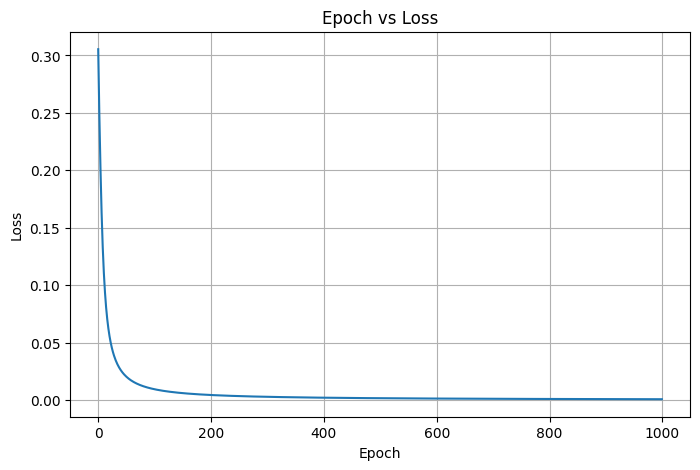

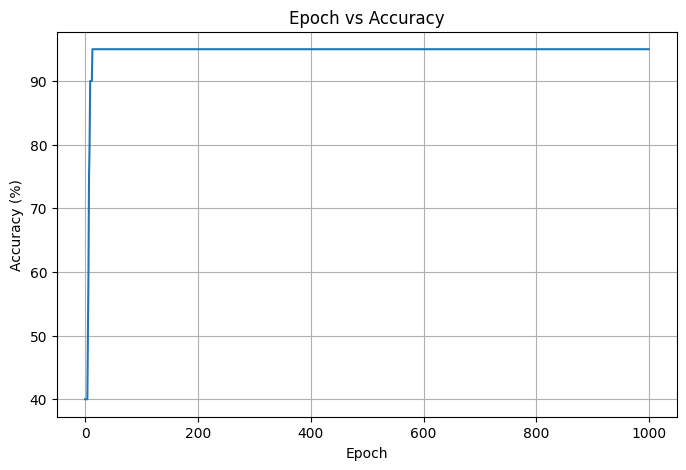

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import csv
import random
import math
import matplotlib.pyplot as plt



file_path = "/content/drive/MyDrive/Dataset/Iris.csv"



X = []
y = []

with open(file_path, "r") as file:

    reader = csv.DictReader(file)

    print("Columns:", reader.fieldnames)

    for row in reader:

        species = row["Species"].strip()

        if species == "Iris-setosa":
            label = 0

        elif species == "Iris-versicolor":
            label = 1

        else:
            continue

        features = [
            float(row["SepalLengthCm"]),
            float(row["SepalWidthCm"]),
            float(row["PetalLengthCm"]),
            float(row["PetalWidthCm"])
        ]

        X.append(features)
        y.append(label)

print("\nTotal Samples:", len(X))

# ==================================
# Normalization
# ==================================

num_features = len(X[0])

for j in range(num_features):

    values = []

    for i in range(len(X)):
        values.append(X[i][j])

    min_val = min(values)
    max_val = max(values)

    for i in range(len(X)):
        X[i][j] = (X[i][j] - min_val) / (max_val - min_val)

# ==================================
# Train Test Split
# ==================================

dataset = list(zip(X, y))

random.shuffle(dataset)

split_index = int(0.8 * len(dataset))

train_data = dataset[:split_index]
test_data = dataset[split_index:]

print("Training Samples :", len(train_data))
print("Testing Samples  :", len(test_data))

# ==================================
# Initialize Weights
# ==================================

weights = []

for i in range(num_features):
    weights.append(random.uniform(-1, 1))

initial_weights = weights.copy()

# Fixed Bias
bias = 1

learning_rate = 0.1
epochs = 1000

# ==================================
# Sigmoid Function
# ==================================

def sigmoid(z):
    return 1 / (1 + math.exp(-z))

# ==================================
# Training
# ==================================

loss_history = []
accuracy_history = []

for epoch in range(epochs):

    total_loss = 0

    for features, target in train_data:

        # Forward Propagation
        z = bias

        for i in range(num_features):
            z += weights[i] * features[i]

        output = sigmoid(z)

        # Error
        error = target - output

        loss = error ** 2
        total_loss += loss

        # Gradient
        gradient = error * output * (1 - output)

        # Update ONLY weights
        for i in range(num_features):
            weights[i] += learning_rate * gradient * features[i]

    avg_loss = total_loss / len(train_data)

    loss_history.append(avg_loss)

    # ==================================
    # Accuracy for Current Epoch
    # ==================================

    correct = 0

    for features, target in test_data:

        z = bias

        for i in range(num_features):
            z += weights[i] * features[i]

        output = sigmoid(z)

        prediction = 1 if output >= 0.5 else 0

        if prediction == target:
            correct += 1

    epoch_accuracy = (correct / len(test_data)) * 100

    accuracy_history.append(epoch_accuracy)

    if epoch % 100 == 0:
        print(
            "Epoch =", epoch,
            " Loss =", round(avg_loss, 6),
            " Accuracy =", round(epoch_accuracy, 2), "%"
        )

# ==================================
# Final Testing
# ==================================

correct = 0

for features, target in test_data:

    z = bias

    for i in range(num_features):
        z += weights[i] * features[i]

    output = sigmoid(z)

    prediction = 1 if output >= 0.5 else 0

    if prediction == target:
        correct += 1

accuracy = (correct / len(test_data)) * 100

# ==================================
# Results
# ==================================

print("\n========== INITIAL WEIGHTS ==========")

for i in range(len(initial_weights)):
    print("W" + str(i+1), "=", round(initial_weights[i], 4))

print("\n========== FINAL WEIGHTS ==========")

for i in range(len(weights)):
    print("W" + str(i+1), "=", round(weights[i], 4))

print("\nFixed Bias =", bias)

print("\nFinal Accuracy =", round(accuracy, 2), "%")

# ==================================
# Loss Graph
# ==================================

plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Loss")
plt.grid(True)
plt.show()

# ==================================
# Accuracy Graph
# ==================================

plt.figure(figsize=(8,5))
plt.plot(accuracy_history)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Epoch vs Accuracy")
plt.grid(True)
plt.show()